# Time Window Neural Decoding - Enhanced Analysis

**Key Questions:**
1. How do different conditions (GS, GNS, NGNS) compare across time windows?
2. Which electrodes show the strongest decoding performance?
3. Are top electrodes consistent across models or model-specific?
4. Do top electrodes show signs of overfitting (train vs test gaps)?
5. Which brain regions contain the most predictive electrodes?

## 1. Setup and Configuration

In [44]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from matplotlib.gridspec import GridSpec
from scipy import stats
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Brain plotting
import mne
from mne.datasets import fetch_fsaverage

# Try to import constants, fallback if not available
try:
    from helpers.constants import *
except:
    print("Warning: helpers.constants not found, using default paths")

# Enhanced plotting configuration for publication quality
plt.style.use('seaborn-v0_8-white')
sns.set_context('paper', font_scale=1.8)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 20,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'axes.linewidth': 1.5,
    'grid.linewidth': 0.8,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

%matplotlib inline

print("✓ Setup complete")

✓ Setup complete


In [ ]:
# Configuration
RESULTS_DIR = "results_selective_windows"
ELEC_PATH = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat"

# Analysis parameters
SUBJECTS = [1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17]
CONDITIONS = ["a", "v", "GS", "NGNS", "GNS"]
SEMANTIC_CONDITIONS = ["GS", "GNS", "NGNS"]  # Focus conditions
LAYERS = ['last', 'late', 'early', 'middle']
TIME_WINDOWS = ['W2', 'W3', 'W4', 'full_consolidation']
MODELS = ['BERT', 'GPT', 'T5']

# Thresholds
R2_THRESHOLD = 0.1
P_VALUE_THRESH_05 = 0.05
P_VALUE_THRESH_01 = 0.01
TOP_N_ELECTRODES = 20  

# Consistent color scheme
MODEL_COLORS = {
    'BERT': '#6B90B5',
    'GPT': '#A36B8C',
    'T5': '#D9A05F',
}

TIME_WINDOW_COLORS = {
    'W2': '#627C85',
    'W3': '#779CAB',
    'W4': "#35524A",
    'full_consolidation': '#A2E8DD'
}

CONDITION_COLORS = {
    'overall': '#8a9499', 
    'a': '#c0392b',       
    'v': '#4a6f8a',       
    'GS': '#5f8f6f',      
    'NGNS': '#b08a4f',     
    'GNS': '#7d6b8f'      
}

MODEL_MARKERS = {
    'BERT': 'o',
    'GPT': 'x',
    'T5': '^'
}

TIME_WINDOW_LABELS = {
    'W2': 'Word 2',
    'W3': 'Word 3',
    'W4': 'Word 4\n(Final)',
    'full_consolidation': 'Consolidation\n(Post-sentence)'
}

# Create output directory
os.makedirs('figures/enhanced_analysis_pvalue', exist_ok=True)

print("✓ Configuration loaded")
print(f"  Results directory: {RESULTS_DIR}")
print(f"  Models: {MODELS}")
print(f"  Time windows: {TIME_WINDOWS}")
print(f"  Focus conditions: {SEMANTIC_CONDITIONS}")

✓ Configuration loaded
  Results directory: results_selective_windows
  Models: ['BERT', 'GPT', 'T5']
  Time windows: ['W2', 'W3', 'W4', 'full_consolidation']
  Focus conditions: ['GS', 'GNS', 'NGNS']


## 2. Helper Functions

In [46]:
def add_significance_stars(p_value):
    """Convert p-value to significance stars."""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

def format_p_value(p_value):
    """Format p-value for display."""
    if p_value < 0.001:
        return 'p < 0.001'
    else:
        return f'p = {p_value:.3f}'

def calculate_permutation_test(group1, group2, n_permutations=10000):
    """
    Perform permutation test for comparing two groups.
    """
    observed_diff = np.mean(group1) - np.mean(group2)
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    
    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_diff = np.mean(combined[:n1]) - np.mean(combined[n1:])
        perm_diffs.append(perm_diff)
    
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return p_value

def add_panel_label(ax, label, x=-0.15, y=1.05):
    """Add panel label (A, B, C, etc.) to subplot."""
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='right')

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Load Data

**Using your existing loading logic - DO NOT MODIFY THIS SECTION**

Loaded electrode data: 1378 electrodes
Columns: ['subjectNum', 'elecNum', 'isRejectManual', 'parcLabel', 'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL', 'isWM', 'unknown_wmParc']...

Loading results across all time windows...

Loading Subject 1...
  a/last/W2: 330 electrodes
  a/last/W3: 330 electrodes
  a/last/W4: 330 electrodes
  a/last/full_consolidation: 330 electrodes
  a/late/W2: 330 electrodes
  a/late/W3: 330 electrodes
  a/late/W4: 330 electrodes
  a/late/full_consolidation: 330 electrodes
  a/early/W2: 330 electrodes
  a/early/W3: 330 electrodes
  a/early/W4: 330 electrodes
  a/early/full_consolidation: 330 electrodes
  a/middle/W2: 330 electrodes
  a/middle/W3: 330 electrodes
  a/middle/W4: 330 electrodes
  a/middle/full_consolidation: 330 electrodes
  v/last/W2: 330 electrodes
  v/last/W3: 330 electrodes
  v/last/W4: 330 electrodes
  v/last/full_consolidation: 330 electrodes
  v/late/W2: 330 electrodes
  v/late/W3: 330 electrodes
  v/late/W4: 330 electrodes
  v/late/

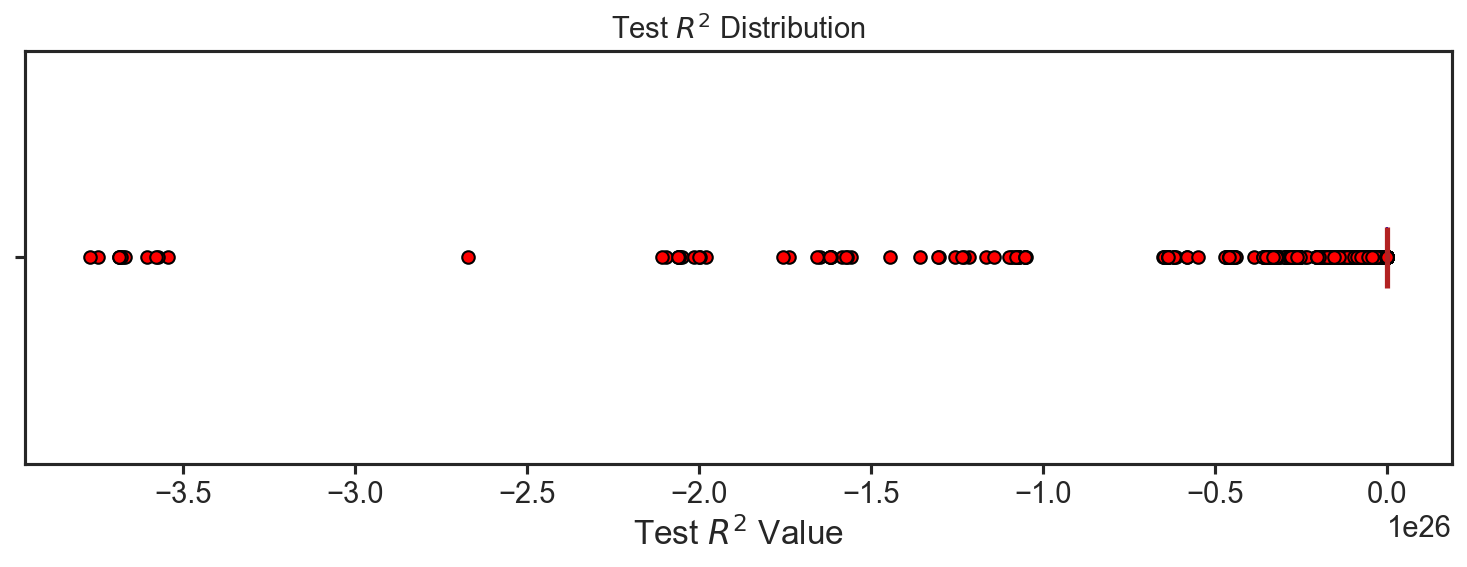


Total dataset: 257 electrode-model-timewindow combinations
Unique electrodes: 69
Unique subjects: 11
Time windows: ['W2', 'W3', 'W4', 'full_consolidation']

Results preview:
       electrode     best_alpha  cv_R_2_mean  train_MSE  test_MSE   train_R  \
21909         24   37275.937203     0.005369   0.919042  0.301767  0.367097   
33163         66    7196.856730    -0.132153   0.493745  0.264670  0.457396   
50590         86  193069.772888    -0.544664   0.435606  0.110648  0.361192   
50942        107    1389.495494    -0.296670   0.066619  0.063644  0.763283   
51109        107   37275.937203    -0.309421   0.098340  0.063807  0.624638   

         test_R  train_R_2  test_R_2 scaler  ... condition  layer  \
21909  0.376566   0.097751  0.116335    NaN  ...       GNS   last   
33163  0.376809   0.095628  0.102254    NaN  ...       GNS   late   
50590  0.408590   0.048833  0.108359    NaN  ...        GS   last   
50942  0.408918   0.427254  0.167063    NaN  ...        GS   last   
51109

In [ ]:

# Load electrode locations
elec_raw = scipy.io.loadmat(ELEC_PATH, squeeze_me=True, simplify_cells=True, struct_as_record=False)
elec_frame = pd.DataFrame(elec_raw['elec_out'])

# Filter out rejected electrodes
elec_frame = elec_frame[(elec_frame['isRejectFSL'] != 1) & 
                          (elec_frame['isRejectManual'] != 1)]

# Add Elec_index for merging
elec_frame['Elec_index'] = elec_frame['elecNum'].astype(int) - 1

print(f"Loaded electrode data: {len(elec_frame)} electrodes")
print(f"Columns: {elec_frame.columns.tolist()[:10]}...")

def load_results(subject, condition, layer, time_window):
    """Load results for specific parameters"""
    path = f"{RESULTS_DIR}/{condition}/{layer}/{time_window}/S{subject}_{condition}_{layer}_{time_window}.pkl"
    
    if not os.path.exists(path):
        return None
    
    with open(path, 'rb') as f:
        return pickle.load(f)

def extract_electrode_data(results, subject_num, elec_frame):
    """Extract and merge electrode data with brain location info"""
    all_data = []
    
    for model_name in ['bert', 'gpt', 't5']:
        results_key = f'{model_name}_results'
        if results_key not in results:
            continue
            
        df = results[results_key].copy()
        df['model'] = model_name.upper()
        
        # Add electrode indices
        df['elec_idx'] = df.index
        
        all_data.append(df)
    
    if not all_data:
        return None
    
    combined = pd.concat(all_data, ignore_index=True)
    
    # Merge with electrode metadata
    subject_elecs = elec_frame[
        (elec_frame['subjectNum'] == subject_num) & 
        (elec_frame['isRejectFSL'] != 1) & 
        (elec_frame['isRejectManual'] != 1)
    ].copy()
    
    merged = pd.merge(
        combined,
        subject_elecs,
        left_on='elec_idx',
        right_on='Elec_index',
        how='inner'
    )
    
    return merged

# Collect all results across time windows
print("\nLoading results across all time windows...")
all_results = []

for subject in SUBJECTS:
    print(f"\nLoading Subject {subject}...")
    
    for condition in CONDITIONS:
        for layer in LAYERS:
            for time_window in TIME_WINDOWS:
                results = load_results(subject, condition, layer, time_window)
                
                if results is None:
                    continue
                
                # Extract electrode data with brain locations
                elec_data = extract_electrode_data(results, subject, elec_frame)
                
                if elec_data is None or len(elec_data) == 0:
                    continue
                
                # Add metadata
                elec_data['subject'] = subject
                elec_data['condition'] = condition
                elec_data['layer'] = layer
                elec_data['time_window'] = time_window
                
                all_results.append(elec_data)
                
                print(f"  {condition}/{layer}/{time_window}: {len(elec_data)} electrodes")

# Combine all results
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    results_df['significance'] = results_df['p_value'].apply(add_significance_stars)
    results_df['train_test_gap'] = results_df['train_R_2'] - results_df['test_R_2']
    results_df['significant'] = results_df['p_value'] < P_VALUE_THRESH_05
    results_df['above_threshold'] = results_df['test_R_2'] > R2_THRESHOLD
    results_df['electrode_id'] = results_df['subject'].astype(str) + '_' + results_df['electrode'].astype(str)
    
    # Distribution before filtering
    fig, ax = plt.subplots(figsize=(10, 4))
    boxprops = dict(linestyle='-', linewidth=1.5, color='blue')
    medianprops = dict(linestyle='-', linewidth=2.5, color='firebrick')
    flierprops = dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none')
    ax.boxplot(results_df['test_R_2'], 
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=medianprops,
            flierprops=flierprops)
    ax.set_title('Test $R^2$ Distribution', fontsize=14)
    ax.set_xlabel('Test $R^2$ Value')
    ax.set_yticklabels([])
    ax.grid(False)
    plt.tight_layout()
    plt.show()
    
    # Apply filters
    results_df = results_df[(results_df['test_R_2'] > -1) & (results_df['test_R_2'] >= R2_THRESHOLD) & (results_df['p_value'] >= P_VALUE_THRESH_05)]
    
    # Add hemisphere label
    results_df['hemisphere'] = results_df['isLeft'].map({1: 'Left', 0: 'Right'})
    if 'elecNum' in results_df.columns:
        results_df['electrode'] = results_df['elecNum']
    
    print(f"\n{'='*80}")
    print(f"Total dataset: {len(results_df)} electrode-model-timewindow combinations")
    print(f"Unique electrodes: {results_df['electrode'].nunique() if 'electrode' in results_df.columns else 'N/A'}")
    print(f"Unique subjects: {results_df['subject'].nunique()}")
    print(f"Time windows: {sorted(results_df['time_window'].unique())}")
    print(f"{'='*80}")
    
    print("\nResults preview:")
    print(results_df.head())
    print(f"\nColumns: {results_df.columns.tolist()}")
else:
    print("ERROR: No results loaded!")
    results_df = pd.DataFrame()

In [48]:
results_df = results_df[(results_df['test_R_2'] >= R2_THRESHOLD)]

In [49]:
results_df

,electrode,best_alpha,cv_R_2_mean,train_MSE,test_MSE,train_R,test_R,train_R_2,test_R_2,scaler,...,condition,layer,time_window,p_value,significance,train_test_gap,significant,above_threshold,electrode_id,hemisphere
21909,24,37275.937203,0.005369,0.919042,0.301767,0.367097,0.376566,0.097751,0.116335,NaN,...,GNS,last,W4,0.18,n.s.,-0.018583,False,True,1_electrode_23,Left
33163,66,7196.856730,-0.132153,0.493745,0.264670,0.457396,0.376809,0.095628,0.102254,NaN,...,GNS,late,W2,0.85,n.s.,-0.006626,False,True,2_electrode_65,Right
50590,86,193069.772888,-0.544664,0.435606,0.110648,0.361192,0.408590,0.048833,0.108359,NaN,...,GS,last,W2,0.22,n.s.,-0.059527,False,True,3_electrode_85,Right
50942,107,1389.495494,-0.296670,0.066619,0.063644,0.763283,0.408918,0.427254,0.167063,NaN,...,GS,last,W3,0.15,n.s.,0.260191,False,True,3_electrode_106,Right
51109,107,37275.937203,-0.309421,0.098340,0.063807,0.624638,0.486029,0.154530,0.164928,NaN,...,GS,last,W3,0.33,n.s.,-0.010398,False,True,3_electrode_106,Right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226066,28,37275.937203,-0.045331,15.872886,1.874147,0.526649,0.400488,0.082197,0.105891,NaN,...,GNS,early,W2,0.40,n.s.,-0.023694,False,True,12_electrode_27,Left
226970,121,193069.772888,-0.539990,11.090335,0.813686,0.519200,0.491861,0.043046,0.134704,NaN,...,GNS,middle,W2,0.46,n.s.,-0.091658,False,True,12_electrode_120,Left
256962,78,7196.856730,-0.011006,16.833422,7.457369,0.649151,0.359422,0.242428,0.115429,NaN,...,NGNS,last,W3,0.65,n.s.,0.126999,False,True,14_electrode_77,Left
308155,8,193069.772888,-0.744388,5.114674,0.801659,0.636363,0.717681,0.051607,0.111290,NaN,...,NGNS,early,W2,0.18,n.s.,-0.059683,False,True,17_electrode_7,Left


## 4. NEW: Condition-Focused Summary Visualizations

These plots focus on **semantic conditions** (GS, GNS, NGNS, overall) rather than time windows.

Saved: figures/enhanced_analysis/condition_summary.png


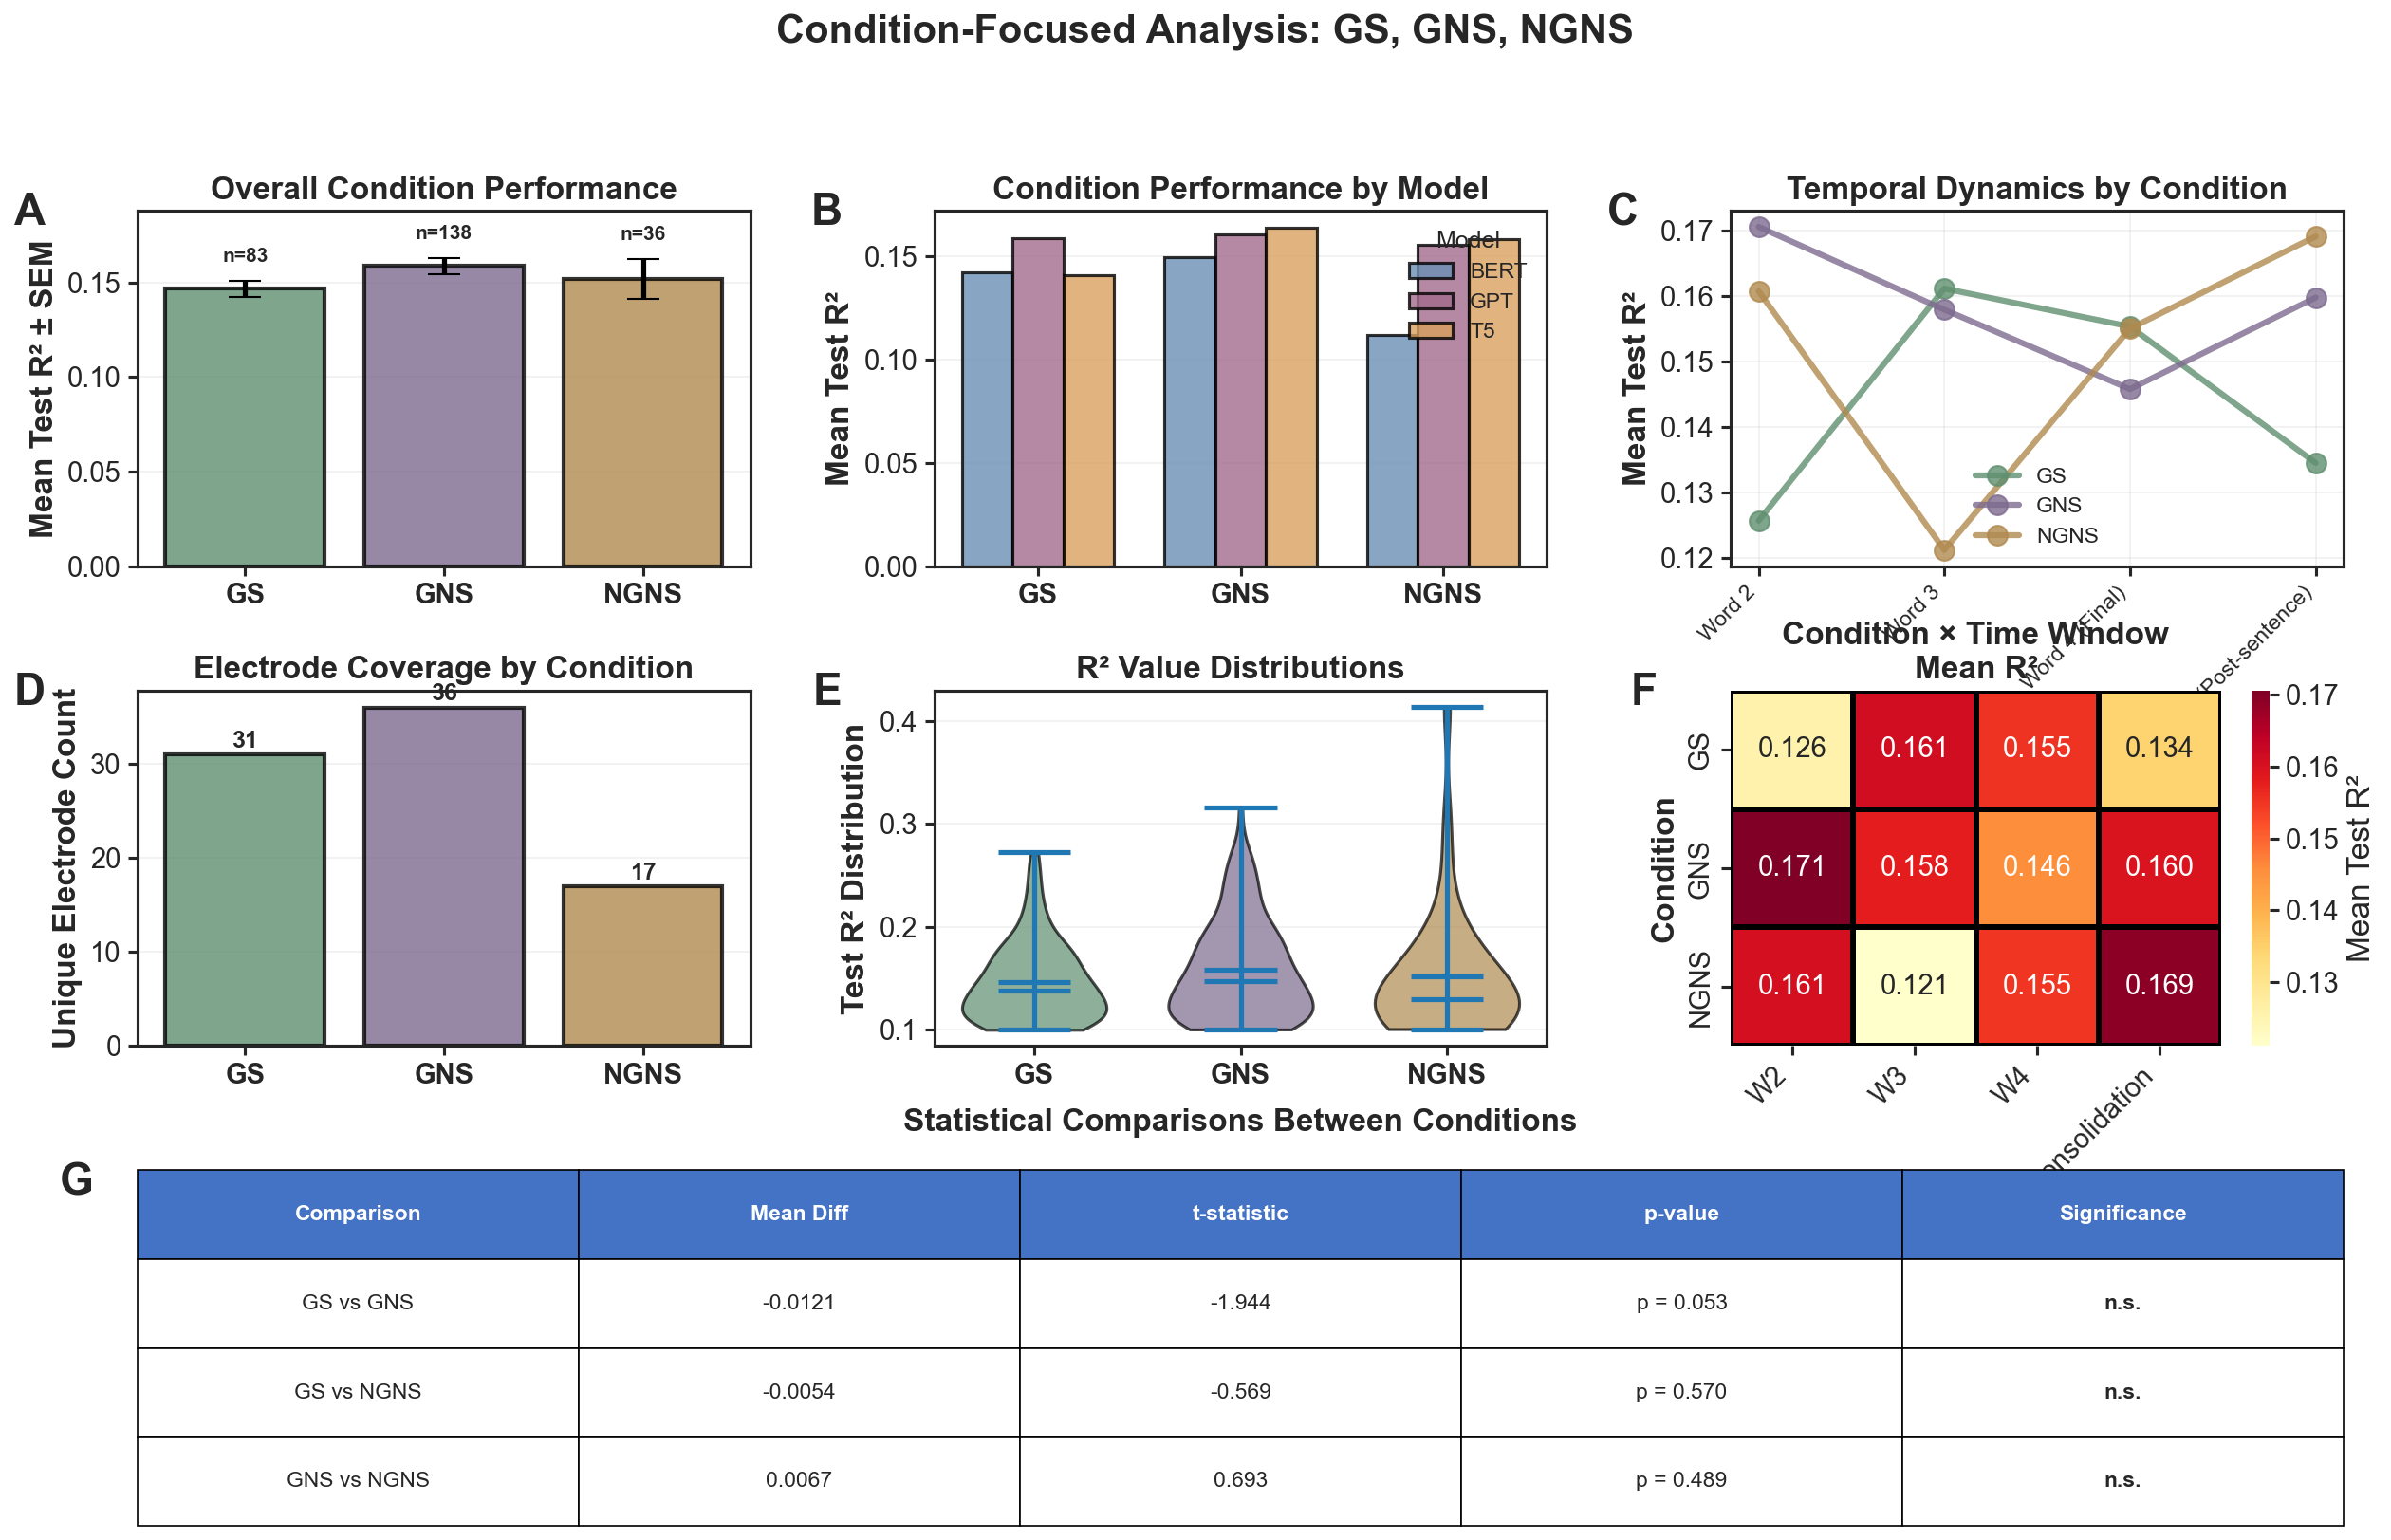

In [ ]:
def plot_condition_summary(df, save_path=None):
    """
    Comprehensive summary of condition performance across models and time windows.
    
    Focus: How do GS, GNS, NGNS, and overall conditions compare?
    """
    # Filter for significant results above threshold
    df_filtered =results_df.copy()
    
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)
    
    # A. Overall condition performance (mean R² across all models/windows)
    ax1 = fig.add_subplot(gs[0, 0])
    
    cond_summary = df_filtered.groupby('condition')['test_R_2'].agg(['mean', 'sem']).reset_index()
    cond_summary = cond_summary[cond_summary['condition'].isin(SEMANTIC_CONDITIONS)]
    cond_summary = cond_summary.set_index('condition').reindex(SEMANTIC_CONDITIONS).reset_index()
    
    bars = ax1.bar(range(len(SEMANTIC_CONDITIONS)), cond_summary['mean'],
                   yerr=cond_summary['sem'], capsize=8,
                   color=[CONDITION_COLORS[c] for c in SEMANTIC_CONDITIONS],
                   edgecolor='black', linewidth=2, alpha=0.8)
    
    ax1.set_xticks(range(len(SEMANTIC_CONDITIONS)))
    ax1.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
    ax1.set_ylabel('Mean Test R² ± SEM', fontweight='bold')
    ax1.set_title('Overall Condition Performance', fontweight='bold', fontsize=16)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, ax1.get_ylim()[1] * 1.1])
    add_panel_label(ax1, 'A')
    
    # Add counts
    for i, cond in enumerate(SEMANTIC_CONDITIONS):
        count = len(df_filtered[df_filtered['condition']==cond])
        mean_val = cond_summary.iloc[i]['mean']
        sem_val = cond_summary.iloc[i]['sem']
        if not pd.isna(mean_val) and not pd.isna(sem_val):
            ax1.text(i, mean_val + sem_val + 0.01,
                    f"n={count}",
                    ha='center', fontsize=10, fontweight='bold')
    
    # B. Condition × Model interaction
    ax2 = fig.add_subplot(gs[0, 1])
    
    cond_model = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        ['condition', 'model'])['test_R_2'].mean().reset_index()
    
    x = np.arange(len(SEMANTIC_CONDITIONS))
    width = 0.25
    
    for i, model in enumerate(MODELS):
        model_data = cond_model[cond_model['model'] == model]
        model_data = model_data.set_index('condition').reindex(SEMANTIC_CONDITIONS).reset_index()
        
        offset = (i - 1) * width
        ax2.bar(x + offset, model_data['test_R_2'], width,
               label=model, color=MODEL_COLORS[model],
               edgecolor='black', linewidth=1.5, alpha=0.8)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
    ax2.set_ylabel('Mean Test R²', fontweight='bold')
    ax2.set_title('Condition Performance by Model', fontweight='bold', fontsize=16)
    ax2.legend(title='Model', fontsize=11, title_fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax2, 'B')
    
    # C. Condition × Time Window interaction
    ax3 = fig.add_subplot(gs[0, 2])
    
    for condition in SEMANTIC_CONDITIONS:
        cond_data = df_filtered[df_filtered['condition'] == condition]
        if len(cond_data) > 0:  # Only plot if data exists
            time_means = cond_data.groupby('time_window')['test_R_2'].mean()
            time_means = time_means.reindex(TIME_WINDOWS)
            
            ax3.plot(range(len(TIME_WINDOWS)), time_means.values,
                    marker='o', linewidth=3, markersize=10,
                    label=condition, color=CONDITION_COLORS[condition],
                    alpha=0.8)
    
    ax3.set_xticks(range(len(TIME_WINDOWS)))
    ax3.set_xticklabels([TIME_WINDOW_LABELS[tw].replace('\n', ' ') for tw in TIME_WINDOWS],
                       rotation=45, ha='right', fontsize=11)
    ax3.set_ylabel('Mean Test R²', fontweight='bold')
    ax3.set_title('Temporal Dynamics by Condition', fontweight='bold', fontsize=16)
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3)
    add_panel_label(ax3, 'C')
    
    # D. Electrode count by condition
    ax4 = fig.add_subplot(gs[1, 0])
    
    cond_counts = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        'condition')['electrode_id'].nunique().reindex(SEMANTIC_CONDITIONS)
    
    bars = ax4.bar(range(len(SEMANTIC_CONDITIONS)), cond_counts.values,
                   color=[CONDITION_COLORS[c] for c in SEMANTIC_CONDITIONS],
                   edgecolor='black', linewidth=2, alpha=0.8)
    
    ax4.set_xticks(range(len(SEMANTIC_CONDITIONS)))
    ax4.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
    ax4.set_ylabel('Unique Electrode Count', fontweight='bold')
    ax4.set_title('Electrode Coverage by Condition', fontweight='bold', fontsize=16)
    ax4.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax4, 'D')
    
    # Add counts on bars - Handle NaN values
    max_count = cond_counts.max()
    for i, count in enumerate(cond_counts.values):
        if not pd.isna(count):
            ax4.text(i, count + max_count * 0.02, str(int(count)),
                    ha='center', fontweight='bold', fontsize=12)
    
    # E. Distribution of R² values by condition (violin plot)
    ax5 = fig.add_subplot(gs[1, 1])
    
    plot_data = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)]
    

    violin_data = []
    violin_positions = []
    violin_labels = []
    
    for i, c in enumerate(SEMANTIC_CONDITIONS):
        cond_values = plot_data[plot_data['condition'] == c]['test_R_2'].values
        if len(cond_values) > 0:  # Only add if there's data
            violin_data.append(cond_values)
            violin_positions.append(i)
            violin_labels.append(c)
    
    if len(violin_data) > 0:  # Only plot if we have any data
        parts = ax5.violinplot(violin_data,
                               positions=violin_positions,
                               widths=0.7, showmeans=True, showmedians=True)
        
        # Color the violins
        for idx, pc in enumerate(parts['bodies']):
            pc.set_facecolor(CONDITION_COLORS[violin_labels[idx]])
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
    
    ax5.set_xticks(range(len(SEMANTIC_CONDITIONS)))
    ax5.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
    ax5.set_ylabel('Test R² Distribution', fontweight='bold')
    ax5.set_title('R² Value Distributions', fontweight='bold', fontsize=16)
    ax5.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax5, 'E')
    
    # F. Heatmap: Condition × Time Window
    ax6 = fig.add_subplot(gs[1, 2])
    
    heatmap_data = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        ['condition', 'time_window'])['test_R_2'].mean().reset_index()
    heatmap_pivot = heatmap_data.pivot(index='condition', columns='time_window', values='test_R_2')
    heatmap_pivot = heatmap_pivot.reindex(index=SEMANTIC_CONDITIONS, columns=TIME_WINDOWS)
    
    sns.heatmap(heatmap_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
               ax=ax6, cbar_kws={'label': 'Mean Test R²'},
               linewidths=2, linecolor='black')
    ax6.set_title('Condition × Time Window\nMean R²', fontweight='bold', fontsize=16)
    ax6.set_xlabel('Time Window', fontweight='bold')
    ax6.set_ylabel('Condition', fontweight='bold')
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
    add_panel_label(ax6, 'F')
    
    # G. Statistical comparison table
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    # Pairwise comparisons between conditions
    comparison_data = []
    comparison_data.append(['Comparison', 'Mean Diff', 't-statistic', 'p-value', 'Significance'])
    
    for i, cond1 in enumerate(SEMANTIC_CONDITIONS):
        for cond2 in SEMANTIC_CONDITIONS[i+1:]:
            data1 = df_filtered[df_filtered['condition'] == cond1]['test_R_2'].values
            data2 = df_filtered[df_filtered['condition'] == cond2]['test_R_2'].values
            
            if len(data1) > 0 and len(data2) > 0:
                t_stat, p_val = stats.ttest_ind(data1, data2)
                mean_diff = np.mean(data1) - np.mean(data2)
                
                comparison_data.append([
                    f"{cond1} vs {cond2}",
                    f"{mean_diff:.4f}",
                    f"{t_stat:.3f}",
                    format_p_value(p_val),
                    add_significance_stars(p_val)
                ])
    
    table = ax7.table(cellText=comparison_data,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Style header row
    for i in range(5):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code significance
    for i in range(1, len(comparison_data)):
        sig = comparison_data[i][4]
        if sig == '***':
            table[(i, 4)].set_facecolor('#d4edda')
        elif sig == '**':
            table[(i, 4)].set_facecolor('#fff3cd')
        elif sig == '*':
            table[(i, 4)].set_facecolor('#f8d7da')
        table[(i, 4)].set_text_props(weight='bold')
    
    ax7.set_title('Statistical Comparisons Between Conditions',
                 fontsize=16, fontweight='bold', pad=20)
    add_panel_label(ax7, 'G', x=-0.02, y=1.02)
    
    plt.suptitle('Condition-Focused Analysis: GS, GNS, NGNS',
                fontsize=20, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig

# Generate plot
fig_condition = plot_condition_summary(results_df, 
                                       save_path='figures/enhanced_analysis/condition_summary.png')

## 5. NEW: Top-Performing Electrode Deep Dive

Granular analysis of the best electrodes: R² values, p-values, which models selected them, and train/test differences.

In [51]:
def identify_top_electrodes(df, n=TOP_N_ELECTRODES):
    """
    Identify top N electrodes based on mean test R² across all conditions.
    """
    # Filter for significant results above threshold
    df_filtered = df.copy()
    
    # Calculate mean performance per electrode
    electrode_performance = df_filtered.groupby('electrode_id').agg({
        'test_R_2': 'mean',
        'train_R_2': 'mean',
        'p_value': 'mean',
        'train_test_gap': 'mean',
        'subject': 'first',
        'parcLabel': 'first'  # Brain region label
    }).reset_index()
    
    # Sort by test R² and get top N
    top_electrodes = electrode_performance.nlargest(n, 'test_R_2')
    
    print(f"\n✓ Identified top {n} electrodes")
    print(f"  Mean R² range: {top_electrodes['test_R_2'].min():.4f} - {top_electrodes['test_R_2'].max():.4f}")
    print(f"  Subjects represented: {top_electrodes['subject'].nunique()}")
    
    return top_electrodes

# Identify top electrodes
top_electrodes = identify_top_electrodes(results_df, n=TOP_N_ELECTRODES)


✓ Identified top 20 electrodes
  Mean R² range: 0.1615 - 0.2455
  Subjects represented: 5


Saved: figures/enhanced_analysis/top_electrodes_analysis.png


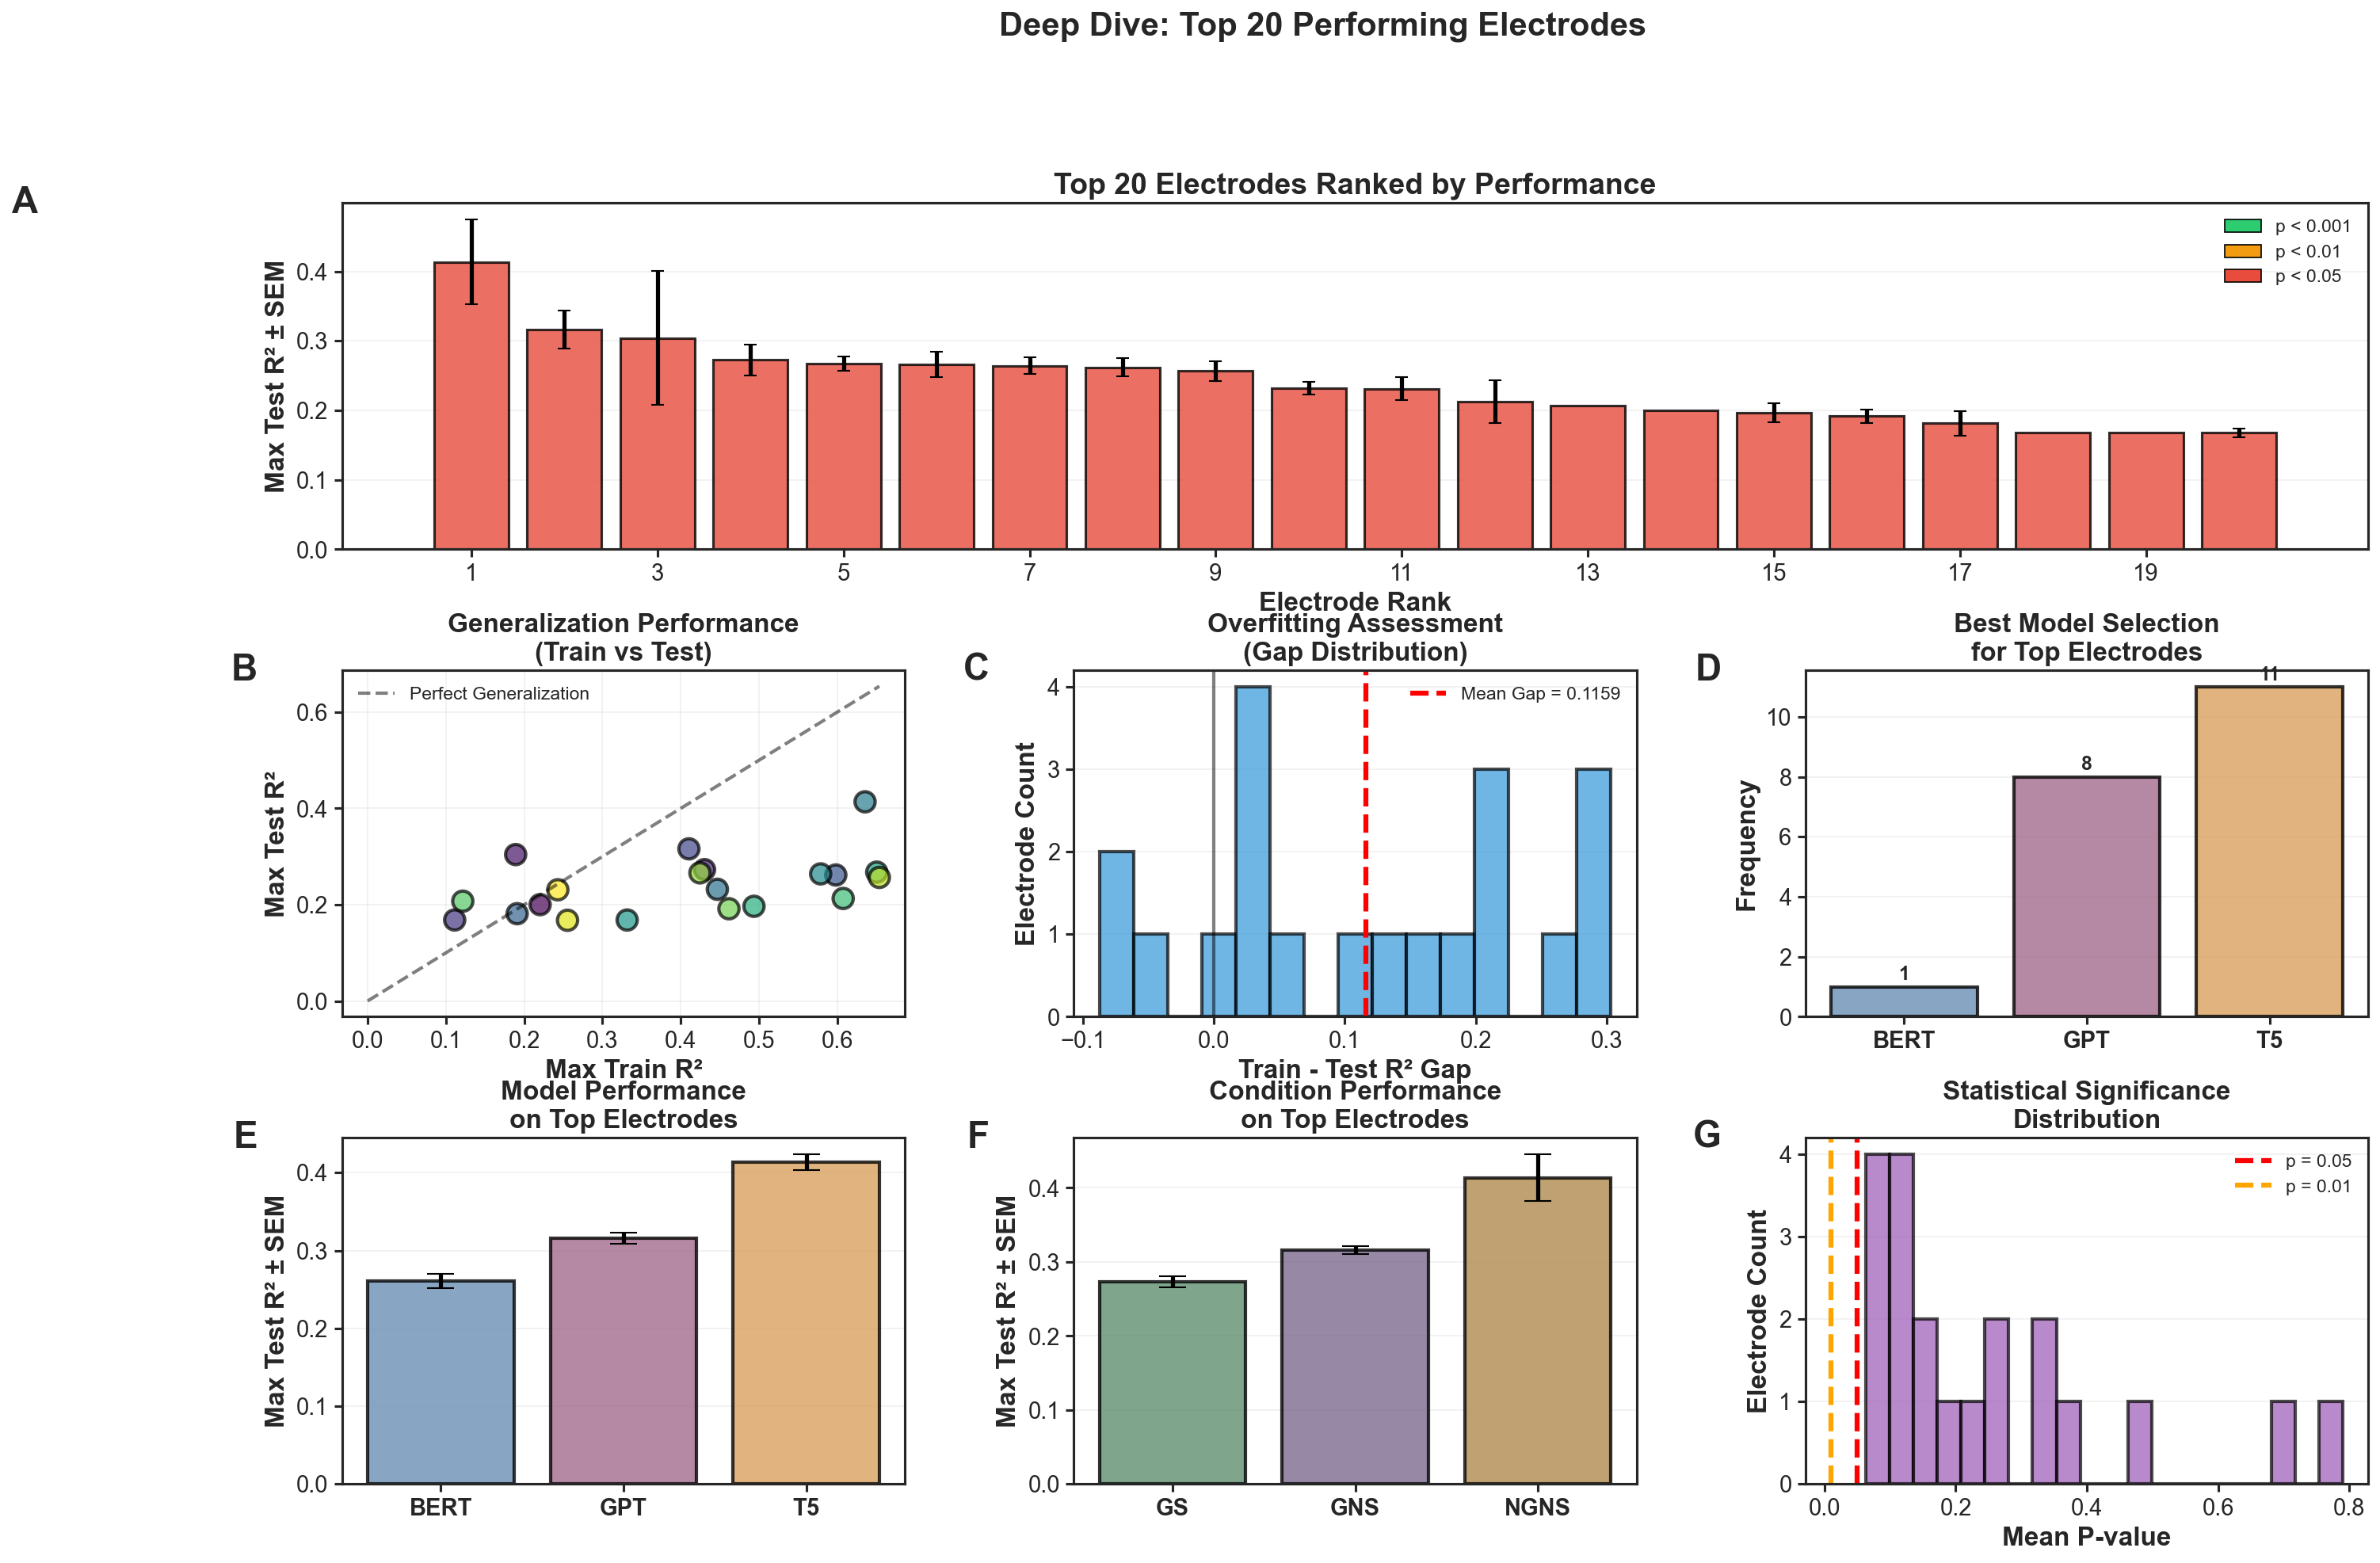

In [52]:
def plot_top_electrodes_analysis(df, top_electrodes_df, save_path=None):
    """
    Comprehensive analysis of top-performing electrodes.
    """
    fig = plt.figure(figsize=(22, 14))
    gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)
    
    # Get data for top electrodes only
    top_elec_ids = top_electrodes_df['electrode_id'].values
    df_top = df[df['electrode_id'].isin(top_elec_ids)].copy()
    
    # A. Ranked R² values with error bars
    ax1 = fig.add_subplot(gs[0, :])
    
    # For each electrode, calculate mean and SEM across conditions
    elec_stats = df_top.groupby('electrode_id').agg({
        'test_R_2': ['max', 'sem'],
        'p_value': 'max'
    }).reset_index()
    elec_stats.columns = ['electrode_id', 'max_r2', 'sem_r2', 'mean_p']
    elec_stats = elec_stats.sort_values('max_r2', ascending=False)
    
    x_pos = np.arange(len(elec_stats))
    colors = ['#2ecc71' if p < 0.001 else '#f39c12' if p < 0.01 else '#e74c3c' 
              for p in elec_stats['mean_p']]
    
    bars = ax1.bar(x_pos, elec_stats['max_r2'], yerr=elec_stats['sem_r2'],
                   capsize=4, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    
    ax1.set_xlabel('Electrode Rank', fontweight='bold')
    ax1.set_ylabel('Max Test R² ± SEM', fontweight='bold')
    ax1.set_title(f'Top {TOP_N_ELECTRODES} Electrodes Ranked by Performance', 
                 fontweight='bold', fontsize=18)
    ax1.set_xticks(x_pos[::2])
    ax1.set_xticklabels(x_pos[::2] + 1)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add legend for p-value colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='p < 0.001'),
        Patch(facecolor='#f39c12', edgecolor='black', label='p < 0.01'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='p < 0.05')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=11)
    add_panel_label(ax1, 'A')
    
    # B. Train vs Test R² (overfitting check)
    ax2 = fig.add_subplot(gs[1, 0])
    
    train_test = df_top.groupby('electrode_id').agg({
        'train_R_2': 'max',
        'test_R_2': 'max'
    }).reset_index()
    
    ax2.scatter(train_test['train_R_2'], train_test['test_R_2'],
               s=150, alpha=0.7, edgecolors='black', linewidths=2,
               c=range(len(train_test)), cmap='viridis')
    
    # Add diagonal line (perfect generalization)
    max_val = max(train_test['train_R_2'].max(), train_test['test_R_2'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=2, alpha=0.5, label='Perfect Generalization')
    
    ax2.set_xlabel('Max Train R²', fontweight='bold')
    ax2.set_ylabel('Max Test R²', fontweight='bold')
    ax2.set_title('Generalization Performance\n(Train vs Test)', 
                 fontweight='bold', fontsize=16)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    add_panel_label(ax2, 'B')
    
    # C. Train-Test Gap distribution
    ax3 = fig.add_subplot(gs[1, 1])
    
    gap_data = df_top.groupby('electrode_id')['train_test_gap'].mean().values
    
    ax3.hist(gap_data, bins=15, edgecolor='black', linewidth=2,
            color='#3498db', alpha=0.7)
    ax3.axvline(gap_data.mean(), color='red', linestyle='--', linewidth=3,
               label=f'Mean Gap = {gap_data.mean():.4f}')
    ax3.axvline(0, color='black', linestyle='-', linewidth=2, alpha=0.5)
    
    ax3.set_xlabel('Train - Test R² Gap', fontweight='bold')
    ax3.set_ylabel('Electrode Count', fontweight='bold')
    ax3.set_title('Overfitting Assessment\n(Gap Distribution)', 
                 fontweight='bold', fontsize=16)
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax3, 'C')
    
    # D. Model selection frequency
    ax4 = fig.add_subplot(gs[1, 2])
    
    # Count how many times each model was "best" for each electrode
    best_model_counts = []
    for elec_id in top_elec_ids:
        elec_data = df_top[df_top['electrode_id'] == elec_id]
        best_model = elec_data.groupby('model')['test_R_2'].max().idxmax()
        best_model_counts.append(best_model)
    
    model_freq = pd.Series(best_model_counts).value_counts().reindex(MODELS, fill_value=0)
    
    bars = ax4.bar(range(len(MODELS)), model_freq.values,
                   color=[MODEL_COLORS[m] for m in MODELS],
                   edgecolor='black', linewidth=2, alpha=0.8)
    
    ax4.set_xticks(range(len(MODELS)))
    ax4.set_xticklabels(MODELS, fontweight='bold')
    ax4.set_ylabel('Frequency', fontweight='bold')
    ax4.set_title('Best Model Selection\nfor Top Electrodes', 
                 fontweight='bold', fontsize=16)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add counts on bars
    for i, count in enumerate(model_freq.values):
        ax4.text(i, count + max(model_freq) * 0.02, str(int(count)),
                ha='center', fontweight='bold', fontsize=12)
    add_panel_label(ax4, 'D')
    
    # E. Performance by model for top electrodes
    ax5 = fig.add_subplot(gs[2, 0])
    
    model_perf = df_top.groupby('model')['test_R_2'].agg(['max', 'sem']).reset_index()
    model_perf = model_perf.set_index('model').reindex(MODELS).reset_index()
    
    ax5.bar(range(len(MODELS)), model_perf['max'], yerr=model_perf['sem'],
           capsize=8, color=[MODEL_COLORS[m] for m in MODELS],
           edgecolor='black', linewidth=2, alpha=0.8)
    
    ax5.set_xticks(range(len(MODELS)))
    ax5.set_xticklabels(MODELS, fontweight='bold')
    ax5.set_ylabel('Max Test R² ± SEM', fontweight='bold')
    ax5.set_title('Model Performance\non Top Electrodes', 
                 fontweight='bold', fontsize=16)
    ax5.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax5, 'E')
    
    # F. Condition breakdown for top electrodes
    ax6 = fig.add_subplot(gs[2, 1])
    
    cond_perf = df_top[df_top['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        'condition')['test_R_2'].agg(['max', 'sem']).reset_index()
    cond_perf = cond_perf.set_index('condition').reindex(SEMANTIC_CONDITIONS).reset_index()
    
    ax6.bar(range(len(SEMANTIC_CONDITIONS)), cond_perf['max'], yerr=cond_perf['sem'],
           capsize=8, color=[CONDITION_COLORS[c] for c in SEMANTIC_CONDITIONS],
           edgecolor='black', linewidth=2, alpha=0.8)
    
    ax6.set_xticks(range(len(SEMANTIC_CONDITIONS)))
    ax6.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
    ax6.set_ylabel('Max Test R² ± SEM', fontweight='bold')
    ax6.set_title('Condition Performance\non Top Electrodes', 
                 fontweight='bold', fontsize=16)
    ax6.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax6, 'F')
    
    # G. P-value distribution
    ax7 = fig.add_subplot(gs[2, 2])
    
    p_values = df_top.groupby('electrode_id')['p_value'].mean().values
    
    ax7.hist(p_values, bins=20, edgecolor='black', linewidth=2,
            color='#9b59b6', alpha=0.7)
    ax7.axvline(0.05, color='red', linestyle='--', linewidth=3, label='p = 0.05')
    ax7.axvline(0.01, color='orange', linestyle='--', linewidth=3, label='p = 0.01')
    
    ax7.set_xlabel('Mean P-value', fontweight='bold')
    ax7.set_ylabel('Electrode Count', fontweight='bold')
    ax7.set_title('Statistical Significance\nDistribution', 
                 fontweight='bold', fontsize=16)
    ax7.legend(fontsize=11)
    ax7.grid(True, alpha=0.3, axis='y')
    add_panel_label(ax7, 'G')
    
    plt.suptitle(f'Deep Dive: Top {TOP_N_ELECTRODES} Performing Electrodes',
                fontsize=20, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig

# Generate analysis plot
fig_top = plot_top_electrodes_analysis(results_df, top_electrodes,
                                       save_path='figures/enhanced_analysis/top_electrodes_analysis.png')

## 6. Detailed Top Electrode Table

Create a comprehensive table with all metrics for top electrodes.

In [53]:
def create_top_electrode_table(df, top_electrodes_df, save_path=None):
    """
    Create detailed table of top electrode metrics using parcLabel for brain region.
    """
    top_elec_ids = top_electrodes_df['electrode_id'].values
    df_top = df[df['electrode_id'].isin(top_elec_ids)].copy()
    
    # Calculate detailed statistics for each electrode
    electrode_details = []
    
    for elec_id in top_elec_ids:
        elec_data = df_top[df_top['electrode_id'] == elec_id]
        
        # Overall metrics
        mean_test_r2 = elec_data['test_R_2'].mean()
        mean_train_r2 = elec_data['train_R_2'].mean()
        mean_gap = elec_data['train_test_gap'].mean()
        mean_p = elec_data['p_value'].mean()
        
        # Best model
        best_model = elec_data.groupby('model')['test_R_2'].mean().idxmax()
        best_model_r2 = elec_data[elec_data['model'] == best_model]['test_R_2'].mean()
        
        # Best condition
        best_condition = elec_data.groupby('condition')['test_R_2'].mean().idxmax()
        best_cond_r2 = elec_data[elec_data['condition'] == best_condition]['test_R_2'].mean()
        
        # Best time window
        best_window = elec_data.groupby('time_window')['test_R_2'].mean().idxmax()
        best_window_r2 = elec_data[elec_data['time_window'] == best_window]['test_R_2'].mean()
        
        # Metadata - using parcLabel for brain region
        subject = elec_data['subject'].iloc[0]
        brain_region = elec_data['parcLabel'].iloc[0] if 'parcLabel' in elec_data.columns and pd.notna(elec_data['parcLabel'].iloc[0]) else 'Unknown'
        hemisphere = elec_data['hemisphere'].iloc[0] if 'hemisphere' in elec_data.columns else 'Unknown'
        
        electrode_details.append({
            'Electrode ID': elec_id,
            'Subject': subject,
            'Brain Region': brain_region,
            'Hemisphere': hemisphere,
            'Mean Test R²': f'{mean_test_r2:.4f}',
            'Mean Train R²': f'{mean_train_r2:.4f}',
            'Train-Test Gap': f'{mean_gap:.4f}',
            'Mean p-value': f'{mean_p:.4f}',
            'Best Model': best_model,
            'Best Model R²': f'{best_model_r2:.4f}',
            'Best Condition': best_condition,
            'Best Cond R²': f'{best_cond_r2:.4f}',
            'Best Window': best_window,
            'Best Window R²': f'{best_window_r2:.4f}'
        })
    
    detail_df = pd.DataFrame(electrode_details)
    detail_df = detail_df.sort_values('Mean Test R²', ascending=False)
    detail_df.insert(0, 'Rank', range(1, len(detail_df) + 1))
    
    if save_path:
        detail_df.to_csv(save_path, index=False)
        print(f"\n✓ Saved detailed electrode table to {save_path}")
    
    return detail_df

# Create and display table
electrode_table = create_top_electrode_table(results_df, top_electrodes,
                                            save_path='figures/enhanced_analysis/top_electrodes_detailed.csv')

print("\nTop 10 Electrodes:")
print(electrode_table.head(10).to_string(index=False))


✓ Saved detailed electrode table to figures/enhanced_analysis/top_electrodes_detailed.csv

Top 10 Electrodes:
 Rank    Electrode ID  Subject            Brain Region Hemisphere Mean Test R² Mean Train R² Train-Test Gap Mean p-value Best Model Best Model R² Best Condition Best Cond R²        Best Window Best Window R²
    1  3_electrode_44        3      G_and_S_cingul-Ant      Right       0.2455        0.4546         0.2091       0.0725        GPT        0.2561           NGNS       0.2455 full_consolidation         0.2455
    2 3_electrode_169        3          S_temporal_sup      Right       0.2243        0.4449         0.2206       0.1950         T5        0.2377            GNS       0.2243                 W4         0.2406
    3  17_electrode_7       17      G_and_S_cingul-Ant       Left       0.2077        0.1204        -0.0873       0.1250        GPT        0.2077           NGNS       0.2077                 W2         0.2077
    4  3_electrode_63        3          G_front_middle   

## 7. Individual Electrode Profiles

Visualize the top 5 electrodes in detail showing their performance across all dimensions.

In [ ]:
def plot_individual_electrode_profiles(df, n_electrodes=5, save_path=None):
    """
    Create detailed profile for each of the top N significant electrodes using parcLabel.
    Ranks electrodes by R² among significant ones only (p_value < 0.05).
    """
    # Get electrode-level summary
    electrode_summary = df.groupby('electrode_id').agg({
        'test_R_2': 'mean',
        'train_R_2': 'mean',
        'p_value': 'first',
        'train_test_gap': 'mean',
        'subject': 'first',
        'parcLabel': 'first'
    }).reset_index()
    
    # Filter for significant electrodes (p < 0.05)
    significant_electrodes = electrode_summary[electrode_summary['p_value'] < 0.05].copy()
    
    if len(significant_electrodes) == 0:
        print("Warning: No significant electrodes found (p < 0.05)!")
        return None
    
    significant_electrodes = significant_electrodes.sort_values('test_R_2', ascending=False)
    
    # Take top n_electrodes
    top_elec_ids = significant_electrodes['electrode_id'].values[:n_electrodes]
    actual_n = len(top_elec_ids)
    
    if actual_n < n_electrodes:
        print(f"Warning: Only {actual_n} significant electrodes available (requested {n_electrodes})")
    
    print(f"\nTop {actual_n} Significant Electrodes:")
    for i, elec_id in enumerate(top_elec_ids):
        info = significant_electrodes[significant_electrodes['electrode_id'] == elec_id].iloc[0]
        print(f"{i+1}. {elec_id}: R²={info['test_R_2']:.4f}, p={info['p_value']:.4f}, {info['parcLabel']}")
    
    fig, axes = plt.subplots(actual_n, 4, figsize=(20, 4*actual_n))
    if actual_n == 1:
        axes = axes.reshape(1, -1)
    
    for row, elec_id in enumerate(top_elec_ids):
        elec_data = df[df['electrode_id'] == elec_id]
        elec_info = significant_electrodes[significant_electrodes['electrode_id'] == elec_id].iloc[0]
        
        subject = elec_info['subject']
        region = elec_info['parcLabel'] if pd.notna(elec_info['parcLabel']) else 'Unknown'
        r2_value = elec_info['test_R_2']
        p_value = elec_info['p_value']
        
        # Determine significance stars
        if p_value < 0.001:
            sig_stars = '***'
        elif p_value < 0.01:
            sig_stars = '**'
        elif p_value < 0.05:
            sig_stars = '*'
        else:
            sig_stars = ''
        
        # Column 1: Performance by model
        ax = axes[row, 0]
        model_perf = elec_data.groupby('model')['test_R_2'].mean().reindex(MODELS)
        bars = ax.bar(range(len(MODELS)), model_perf.values,
                     edgecolor='black', linewidth=2, alpha=0.8)
        ax.set_xticks(range(len(MODELS)))
        ax.set_xticklabels(MODELS, fontweight='bold')
        ax.set_ylabel('Mean Test R²', fontweight='bold')
        ax.set_title(f'Rank {row+1}: {elec_id} {sig_stars}\nSubj {subject}, {region}\nR²={r2_value:.4f}, p={p_value:.4f}', 
                    fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Column 2: Performance by condition
        ax = axes[row, 1]
        cond_perf = elec_data[elec_data['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
            'condition')['test_R_2'].mean().reindex(SEMANTIC_CONDITIONS)
        ax.bar(range(len(SEMANTIC_CONDITIONS)), cond_perf.values,
              edgecolor='black', linewidth=2, alpha=0.8)
        ax.set_xticks(range(len(SEMANTIC_CONDITIONS)))
        ax.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
        ax.set_ylabel('Mean Test R²', fontweight='bold')
        ax.set_title('By Condition', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Column 3: Performance by time window
        ax = axes[row, 2]
        time_perf = elec_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)

        ax.bar(range(len(TIME_WINDOWS)), time_perf.values, 
            color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)

        ax.set_xticks(range(len(TIME_WINDOWS)))
        ax.set_xticklabels([tw.replace('_', '\n') for tw in TIME_WINDOWS], 
                        rotation=0, fontsize=9)
        ax.set_ylabel('Mean Test R²', fontweight='bold')
        ax.set_title('Temporal Profile', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Column 4: Train vs Test comparison
        ax = axes[row, 3]
        train_vals = elec_data['train_R_2'].values
        test_vals = elec_data['test_R_2'].values
        
        ax.scatter(train_vals, test_vals, s=80, alpha=0.6,
                  edgecolors='black', linewidths=1.5, c='#e74c3c')
        max_val = max(train_vals.max(), test_vals.max())
        ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, alpha=0.5)
        
        mean_gap = elec_info['train_test_gap']
        ax.set_xlabel('Train R²', fontweight='bold')
        ax.set_ylabel('Test R²', fontweight='bold')
        ax.set_title(f'Generalization\nMean Gap: {mean_gap:.4f}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Individual Profiles: Top {actual_n} Significant Electrodes (p < 0.05)',
                fontsize=20, fontweight='bold')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    return fig

# Generate individual profiles for top 5 significant electrodes
fig_profiles = plot_individual_electrode_profiles(results_df, n_electrodes=5,
                                                 save_path='figures/enhanced_analysis/individual_electrode_profiles.png')

In [55]:
results_df.columns

Index(['electrode', 'best_alpha', 'cv_R_2_mean', 'train_MSE', 'test_MSE',
       'train_R', 'test_R', 'train_R_2', 'test_R_2', 'scaler', 'model',
       'elec_idx', 'subjectNum', 'elecNum', 'isRejectManual', 'parcLabel',
       'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL', 'isWM',
       'unknown_wmParc', 'groupLabels', 'isLeft', 'groupAvgCoords',
       'Elec_index', 'subject', 'condition', 'layer', 'time_window', 'p_value',
       'significance', 'train_test_gap', 'significant', 'above_threshold',
       'electrode_id', 'hemisphere'],
      dtype='object')

In [56]:
top_electrodes

,electrode_id,test_R_2,train_R_2,p_value,train_test_gap,subject,parcLabel
42,3_electrode_44,0.245531,0.454615,0.072500,0.209085,3,G_and_S_cingul-Ant
27,3_electrode_169,0.224311,0.444876,0.195000,0.220565,3,S_temporal_sup
5,17_electrode_7,0.207692,0.120353,0.125000,-0.087339,17,G_and_S_cingul-Ant
49,3_electrode_63,0.207264,0.121561,0.330000,-0.085703,3,G_front_middle
8,3_electrode_106,0.206091,0.316051,0.224000,0.109960,3,G_Ins_lg_and_S_cent_ins
37,3_electrode_25,0.205699,0.405439,0.165000,0.199740,3,G_front_inf-Triangul
55,3_electrode_82,0.202672,0.345441,0.488333,0.142770,3,G_rectus
21,3_electrode_15,0.201345,0.215394,0.368571,0.014048,3,S_orbital-H_Shaped
0,11_electrode_96,0.200114,0.220361,0.790000,0.020248,11,S_oc_middle_and_Lunatus
65,6_electrode_27,0.198211,0.233060,0.703333,0.034848,6,S_postcentral


Saved: figures/enhanced_analysis/individual_electrode_raw_profiles.png


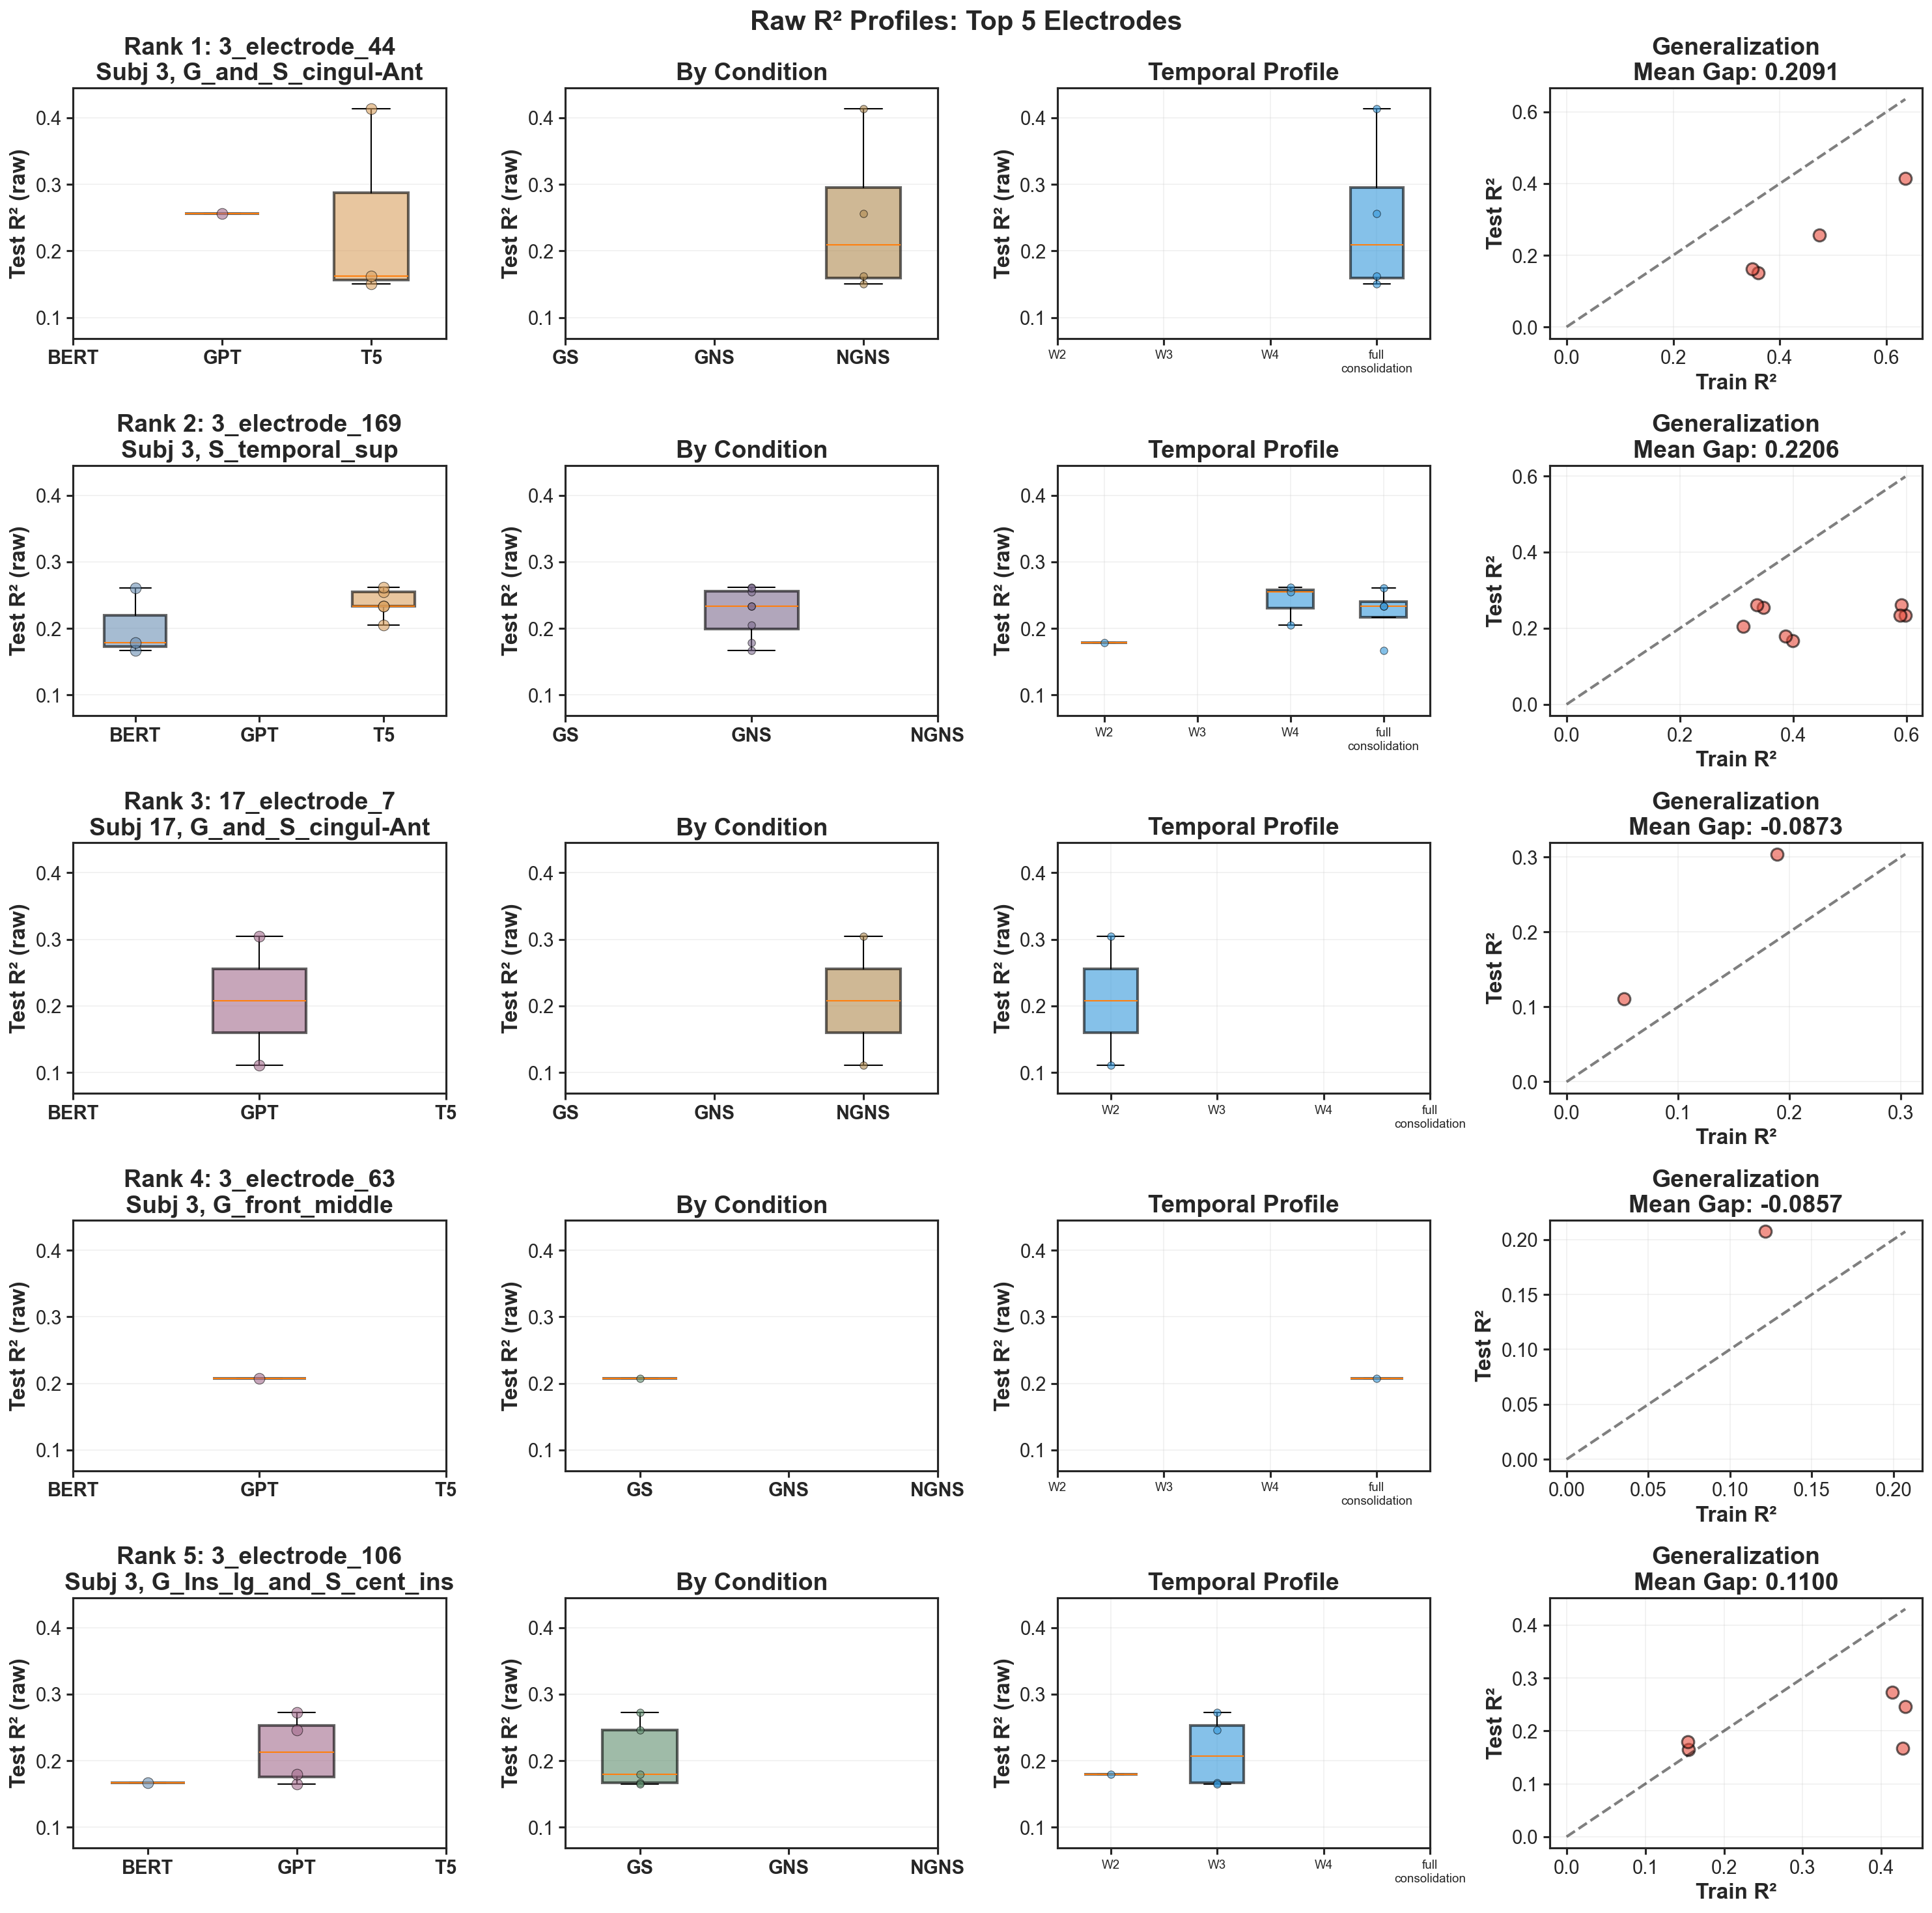

In [ ]:
def plot_individual_electrode_raw_profiles(
    df, top_electrodes_df, n_electrodes=5, save_path=None
):
    """Create detailed profile for each of the top N electrodes showing raw R² values."""

    top_elec_ids = top_electrodes_df['electrode_id'].values[:n_electrodes]

    # Global y-limits
    global_min = df['test_R_2'].min()
    global_max = df['test_R_2'].max()
    padding = (global_max - global_min) * 0.1
    y_min, y_max = global_min - padding, global_max + padding

    fig, axes = plt.subplots(n_electrodes, 4, figsize=(20, 4 * n_electrodes))
    if n_electrodes == 1:
        axes = axes.reshape(1, -1)

    for row, elec_id in enumerate(top_elec_ids):
        elec_data = df[df['electrode_id'] == elec_id]
        subject = elec_data['subject'].iloc[0]
        region = (
            elec_data['parcLabel'].iloc[0]
            if 'parcLabel' in elec_data.columns and pd.notna(elec_data['parcLabel'].iloc[0])
            else 'Unknown'
        )


        ax = axes[row, 0]
        for i, model in enumerate(MODELS):
            model_data = elec_data.loc[
                elec_data['model'] == model, 'test_R_2'
            ].values

            if len(model_data) == 0:
                continue

            bp = ax.boxplot(
                [model_data],
                positions=[i],
                widths=0.5,
                patch_artist=True,
            )
            box = bp['boxes'][0]
            box.set_facecolor(MODEL_COLORS[model])
            box.set_alpha(0.6)
            box.set_edgecolor('black')
            box.set_linewidth(2)


            x = np.full(len(model_data), i)
            ax.scatter(
                x,
                model_data,
                alpha=0.6,
                c=MODEL_COLORS[model],
                edgecolors='black',
                linewidths=0.5,
                zorder=3,
            )

        ax.set_ylim(y_min, y_max)
        ax.set_xticks(range(len(MODELS)))
        ax.set_xticklabels(MODELS, fontweight='bold')
        ax.set_ylabel('Test R² (raw)', fontweight='bold')
        ax.set_title(f'Rank {row+1}: {elec_id}\nSubj {subject}, {region}', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

  
        ax = axes[row, 1]
        for i, cond in enumerate(SEMANTIC_CONDITIONS):
            cond_data = elec_data.loc[
                elec_data['condition'] == cond, 'test_R_2'
            ].values

            if len(cond_data) == 0:
                continue

            bp = ax.boxplot(
                [cond_data],
                positions=[i],
                widths=0.5,
                patch_artist=True,
                showfliers=False,
            )
            box = bp['boxes'][0]
            box.set_facecolor(CONDITION_COLORS[cond])
            box.set_alpha(0.6)
            box.set_edgecolor('black')
            box.set_linewidth(2)

   
            x = np.full(len(cond_data), i)
            ax.scatter(
                x,
                cond_data,
                alpha=0.6,
                s=30,
                c=CONDITION_COLORS[cond],
                edgecolors='black',
                linewidths=0.5,
                zorder=3,
            )

        ax.set_ylim(y_min, y_max)
        ax.set_xticks(range(len(SEMANTIC_CONDITIONS)))
        ax.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold')
        ax.set_ylabel('Test R² (raw)', fontweight='bold')
        ax.set_title('By Condition', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')


        ax = axes[row, 2]
        for i, tw in enumerate(TIME_WINDOWS):
            tw_data = elec_data.loc[
                elec_data['time_window'] == tw, 'test_R_2'
            ].values

            if len(tw_data) == 0:
                continue

            bp = ax.boxplot(
                [tw_data],
                positions=[i],
                widths=0.5,
                patch_artist=True,
                showfliers=False,
            )
            box = bp['boxes'][0]
            box.set_facecolor('#3498db')
            box.set_alpha(0.6)
            box.set_edgecolor('black')
            box.set_linewidth(2)

            # Raw points (NO JITTER)
            x = np.full(len(tw_data), i)
            ax.scatter(
                x,
                tw_data,
                alpha=0.6,
                s=30,
                c='#3498db',
                edgecolors='black',
                linewidths=0.5,
                zorder=3,
            )

        ax.set_ylim(y_min, y_max)
        ax.set_xticks(range(len(TIME_WINDOWS)))
        ax.set_xticklabels(
            [tw.replace('_', '\n') for tw in TIME_WINDOWS],
            fontsize=9,
        )
        ax.set_ylabel('Test R² (raw)', fontweight='bold')
        ax.set_title('Temporal Profile', fontweight='bold')
        ax.grid(True, alpha=0.3)


        ax = axes[row, 3]
        train_vals = elec_data['train_R_2'].values
        test_vals = elec_data['test_R_2'].values

        ax.scatter(
            train_vals,
            test_vals,
            s=80,
            alpha=0.6,
            edgecolors='black',
            linewidths=1.5,
            c='#e74c3c',
        )

        max_val = max(train_vals.max(), test_vals.max())
        ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, alpha=0.5)

        mean_gap = elec_data['train_test_gap'].mean()
        ax.set_xlabel('Train R²', fontweight='bold')
        ax.set_ylabel('Test R²', fontweight='bold')
        ax.set_title(f'Generalization\nMean Gap: {mean_gap:.4f}', fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Raw R² Profiles: Top {n_electrodes} Electrodes',
        fontsize=20,
        fontweight='bold',
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    return fig
fig_raw_profiles = plot_individual_electrode_raw_profiles(
    results_df, top_electrodes, n_electrodes=5,
    save_path='figures/enhanced_analysis/individual_electrode_raw_profiles.png'
)

## 8. Summary Statistics Export

In [58]:
def export_summary_statistics(df, save_dir='figures/enhanced_analysis'):
    """
    Export comprehensive summary statistics.
    """
    df_filtered = df[(df['significant']) & (df['above_threshold'])].copy()
    
    # 1. Condition summary
    cond_summary = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby('condition').agg({
        'test_R_2': ['mean', 'std', 'sem', 'median'],
        'train_R_2': ['mean', 'std'],
        'train_test_gap': ['mean', 'std'],
        'p_value': ['mean', 'median'],
        'electrode_id': 'nunique'
    }).round(4)
    cond_summary.columns = ['_'.join(col).strip() for col in cond_summary.columns.values]
    cond_summary.to_csv(f'{save_dir}/condition_summary_statistics.csv')
    print(f"✓ Saved condition summary statistics")
    
    # 2. Model summary
    model_summary = df_filtered.groupby('model').agg({
        'test_R_2': ['mean', 'std', 'sem', 'median'],
        'train_R_2': ['mean', 'std'],
        'train_test_gap': ['mean', 'std'],
        'electrode_id': 'nunique'
    }).round(4)
    model_summary.columns = ['_'.join(col).strip() for col in model_summary.columns.values]
    model_summary.to_csv(f'{save_dir}/model_summary_statistics.csv')
    print(f"✓ Saved model summary statistics")
    
    # 3. Time window summary
    time_summary = df_filtered.groupby('time_window').agg({
        'test_R_2': ['mean', 'std', 'sem', 'median'],
        'train_R_2': ['mean', 'std'],
        'electrode_id': 'nunique'
    }).round(4)
    time_summary.columns = ['_'.join(col).strip() for col in time_summary.columns.values]
    time_summary.to_csv(f'{save_dir}/time_window_summary_statistics.csv')
    print(f"✓ Saved time window summary statistics")
    
    # 4. Interaction: Condition × Model
    cond_model = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        ['condition', 'model'])['test_R_2'].agg(['mean', 'std', 'count']).round(4)
    cond_model.to_csv(f'{save_dir}/condition_model_interaction.csv')
    print(f"✓ Saved condition × model interaction")
    
    # 5. Interaction: Condition × Time Window
    cond_time = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        ['condition', 'time_window'])['test_R_2'].agg(['mean', 'std', 'count']).round(4)
    cond_time.to_csv(f'{save_dir}/condition_time_interaction.csv')
    print(f"✓ Saved condition × time window interaction")
    
    print(f"\n✓ All summary statistics exported to {save_dir}/")

# Export all statistics
export_summary_statistics(results_df)

✓ Saved condition summary statistics
✓ Saved model summary statistics
✓ Saved time window summary statistics
✓ Saved condition × model interaction
✓ Saved condition × time window interaction

✓ All summary statistics exported to figures/enhanced_analysis/


## 9. Final Summary Report

In [ ]:
def print_final_summary(df, top_electrodes_df):
    """
    Print comprehensive summary of analysis.
    """
    df_filtered = df[(df['significant']) & (df['above_threshold'])].copy()
    
    print("="*80)
    print("ENHANCED TIME WINDOW ANALYSIS - FINAL SUMMARY")
    print("="*80)
    
    print("\n1. OVERALL STATISTICS")
    print("-" * 80)
    print(f"Total electrode observations: {len(df):,}")
    print(f"Significant observations (p<0.05): {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
    print(f"Unique electrodes: {df['electrode_id'].nunique()}")
    print(f"Subjects: {df['subject'].nunique()}")
    print(f"Mean test R²: {df_filtered['test_R_2'].mean():.4f} ± {df_filtered['test_R_2'].sem():.4f}")
    print(f"Mean train-test gap: {df_filtered['train_test_gap'].mean():.4f} ± {df_filtered['train_test_gap'].sem():.4f}")
    
    print("\n2. CONDITION COMPARISON (GS, GNS, NGNS, Overall)")
    print("-" * 80)
    for condition in SEMANTIC_CONDITIONS:
        cond_data = df_filtered[df_filtered['condition'] == condition]['test_R_2']
        print(f"{condition:8s}: R² = {cond_data.mean():.4f} ± {cond_data.sem():.4f}  (n={len(cond_data)})")
    
    print("\n3. MODEL COMPARISON")
    print("-" * 80)
    for model in MODELS:
        model_data = df_filtered[df_filtered['model'] == model]['test_R_2']
        print(f"{model:6s}: R² = {model_data.mean():.4f} ± {model_data.sem():.4f}  (n={len(model_data)})")
    
    print("\n4. TIME WINDOW ANALYSIS")
    print("-" * 80)
    for window in TIME_WINDOWS:
        window_data = df_filtered[df_filtered['time_window'] == window]['test_R_2']
        print(f"{window:20s}: R² = {window_data.mean():.4f} ± {window_data.sem():.4f}  (n={len(window_data)})")
    
    print(f"\n5. TOP {TOP_N_ELECTRODES} ELECTRODES SUMMARY")
    print("-" * 80)
    print(f"Mean test R² range: {top_electrodes_df['test_R_2'].min():.4f} - {top_electrodes_df['test_R_2'].max():.4f}")
    print(f"Mean train-test gap: {top_electrodes_df['train_test_gap'].mean():.4f}")
    print(f"Mean p-value: {top_electrodes_df['p_value'].mean():.6f}")
    print(f"Subjects represented: {top_electrodes_df['subject'].nunique()} / {df['subject'].nunique()}")
    
    # Best model for top electrodes
    top_elec_data = df[df['electrode_id'].isin(top_electrodes_df['electrode_id'])]
    best_models = []
    for elec_id in top_electrodes_df['electrode_id']:
        elec_data = top_elec_data[top_elec_data['electrode_id'] == elec_id]
        best_model = elec_data.groupby('model')['test_R_2'].mean().idxmax()
        best_models.append(best_model)
    
    print("\nBest model distribution:")
    for model in MODELS:
        count = best_models.count(model)
        print(f"  {model}: {count} / {TOP_N_ELECTRODES} ({count/TOP_N_ELECTRODES*100:.1f}%)")
    
    print("\n6. KEY FINDINGS")
    print("-" * 80)
    
    # Find best condition
    best_cond = df_filtered[df_filtered['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
        'condition')['test_R_2'].mean().idxmax()
    best_cond_r2 = df_filtered[df_filtered['condition'] == best_cond]['test_R_2'].mean()
    print(f"• Best performing condition: {best_cond} (R² = {best_cond_r2:.4f})")
    
    # Find best model
    best_model = df_filtered.groupby('model')['test_R_2'].mean().idxmax()
    best_model_r2 = df_filtered[df_filtered['model'] == best_model]['test_R_2'].mean()
    print(f"• Best performing model: {best_model} (R² = {best_model_r2:.4f})")
    
    # Find best time window
    best_window = df_filtered.groupby('time_window')['test_R_2'].mean().idxmax()
    best_window_r2 = df_filtered[df_filtered['time_window'] == best_window]['test_R_2'].mean()
    print(f"• Best performing time window: {best_window} (R² = {best_window_r2:.4f})")
    
    # Overfitting check
    high_gap = df_filtered[df_filtered['train_test_gap'] > 0.1]
    print(f"• Electrodes with high overfitting (gap > 0.1): {len(high_gap)} / {len(df_filtered)} ({len(high_gap)/len(df_filtered)*100:.1f}%)")
    
    print("\n" + "="*80)
    print("Analysis complete! All figures saved to figures/enhanced_analysis/")
    print("="*80)


print_final_summary(results_df, top_electrodes)

ENHANCED TIME WINDOW ANALYSIS - FINAL SUMMARY

1. OVERALL STATISTICS
--------------------------------------------------------------------------------
Total electrode observations: 257
Significant observations (p<0.05): 0 (0.0%)
Unique electrodes: 77
Subjects: 11
Mean test R²: nan ± nan
Mean train-test gap: nan ± nan

2. CONDITION COMPARISON (GS, GNS, NGNS, Overall)
--------------------------------------------------------------------------------
GS      : R² = nan ± nan  (n=0)
GNS     : R² = nan ± nan  (n=0)
NGNS    : R² = nan ± nan  (n=0)

3. MODEL COMPARISON
--------------------------------------------------------------------------------
BERT  : R² = nan ± nan  (n=0)
GPT   : R² = nan ± nan  (n=0)
T5    : R² = nan ± nan  (n=0)

4. TIME WINDOW ANALYSIS
--------------------------------------------------------------------------------
W2                  : R² = nan ± nan  (n=0)
W3                  : R² = nan ± nan  (n=0)
W4                  : R² = nan ± nan  (n=0)
full_consolidation  : R² 

ValueError: attempt to get argmax of an empty sequence